In [7]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
india = gpd.read_file("https://github.com/datameet/maps/raw/master/Districts/Census_2011/2011_Dist.shp")

# PM2.5 grid parameters
lon_min, lon_max = 68.0, 97.5
lat_min, lat_max = 8.0, 37.5
url = "https://raw.githubusercontent.com/nishusharma1608/India-Census-2011-Analysis/master/india-districts-census-2011.csv"
df_census = pd.read_csv(url)

print("Shapefile loaded:", india.shape)
print("Census loaded:", df_census.shape)
from PIL import Image
import numpy as np
Image.MAX_IMAGE_PIXELS = None

tif_path = r"C:\Users\Arshia4\sdei-global-annual-gwr-pm2-5-modis-misr-seawifs-aod-v4-gl-03-2011.tif"

img = Image.open(tif_path)
print("File loaded successfully!")
print("Image size:", img.size)
print("Image mode:", img.mode)

Shapefile loaded: (641, 6)
Census loaded: (640, 118)
File loaded successfully!
Image size: (36000, 12500)
Image mode: F


In [9]:
import numpy as np

# Cropping to India bounding box
# Image covers: lon -180 to 180, lat -90 to 90 (check with tfw)
# Using the image dimensions to calculate pixel positions

img_width, img_height = img.size  # 36000 x 12500

# Full global extent
lon_min_global, lon_max_global = -180, 180
lat_min_global, lat_max_global = -90, 90

# India bounding box
india_lon_min, india_lon_max = 68.0, 97.5
india_lat_min, india_lat_max = 8.0, 37.5

# Calculate pixel positions
def lon_to_col(lon):
    return int((lon - lon_min_global) / (lon_max_global - lon_min_global) * img_width)

def lat_to_row(lat):
    return int((lat_max_global - lat) / (lat_max_global - lat_min_global) * img_height)

col_start = lon_to_col(india_lon_min)
col_end   = lon_to_col(india_lon_max)
row_start = lat_to_row(india_lat_max)
row_end   = lat_to_row(india_lat_min)

print(f"Cropping to India: rows {row_start}:{row_end}, cols {col_start}:{col_end}")

# Cropping and converting to numpy array
india_crop = img.crop((col_start, row_start, col_end, row_end))
pm25_array = np.array(india_crop, dtype=np.float32)
pm25_array[pm25_array <= 0] = np.nan

print(f"India array shape: {pm25_array.shape}")
print(f"PM2.5 min:  {np.nanmin(pm25_array):.2f} µg/m³")
print(f"PM2.5 max:  {np.nanmax(pm25_array):.2f} µg/m³")
print(f"PM2.5 mean: {np.nanmean(pm25_array):.2f} µg/m³")

Cropping to India: rows 3645:5694, cols 24800:27750
India array shape: (2049, 2950)
PM2.5 min:  2.40 µg/m³
PM2.5 max:  336.50 µg/m³
PM2.5 mean: 44.18 µg/m³


In [10]:
# Assigning PM2.5 to each district using centroid sampling
pixel_size_lon = (india_lon_max - india_lon_min) / pm25_array.shape[1]
pixel_size_lat = (india_lat_max - india_lat_min) / pm25_array.shape[0]

india['centroid_lon'] = india.geometry.centroid.x
india['centroid_lat'] = india.geometry.centroid.y

def get_pm25(lon, lat):
    if lon < india_lon_min or lon > india_lon_max:
        return np.nan
    if lat < india_lat_min or lat > india_lat_max:
        return np.nan
    col = int((lon - india_lon_min) / pixel_size_lon)
    row = int((india_lat_max - lat) / pixel_size_lat)
    row = min(row, pm25_array.shape[0] - 1)
    col = min(col, pm25_array.shape[1] - 1)
    return float(pm25_array[row, col])

india['PM25'] = india.apply(
    lambda r: get_pm25(r['centroid_lon'], r['centroid_lat']), axis=1)

print(f"Districts with PM2.5 data: {india['PM25'].notna().sum()}")
print(f"\nTop 10 most polluted districts:")
print(india[['DISTRICT', 'ST_NM', 'PM25']]\
      .sort_values('PM25', ascending=False).head(10).to_string())

C:\Users\Arshia4\AppData\Local\Temp\ipykernel_11544\1810285959.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  india['centroid_lon'] = india.geometry.centroid.x
C:\Users\Arshia4\AppData\Local\Temp\ipykernel_11544\1810285959.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  india['centroid_lat'] = india.geometry.centroid.y


Districts with PM2.5 data: 634

Top 10 most polluted districts:
                       DISTRICT             ST_NM        PM25
489                  Saharanpur     Uttar Pradesh  141.399994
625                 Yamunanagar           Haryana  140.899994
427                   Panchkula           Haryana  137.100006
106                  Chandigarh        Chandigarh  135.199997
13                       Ambala           Haryana  135.100006
492  Sahibzada Ajit Singh Nagar            Punjab  134.800003
529                     Sirmaur  Himachal Pradesh  134.300003
385               Muzaffarnagar     Uttar Pradesh  133.899994
536                       Solan  Himachal Pradesh  133.699997
221                     Hardwar       Uttarakhand  128.199997


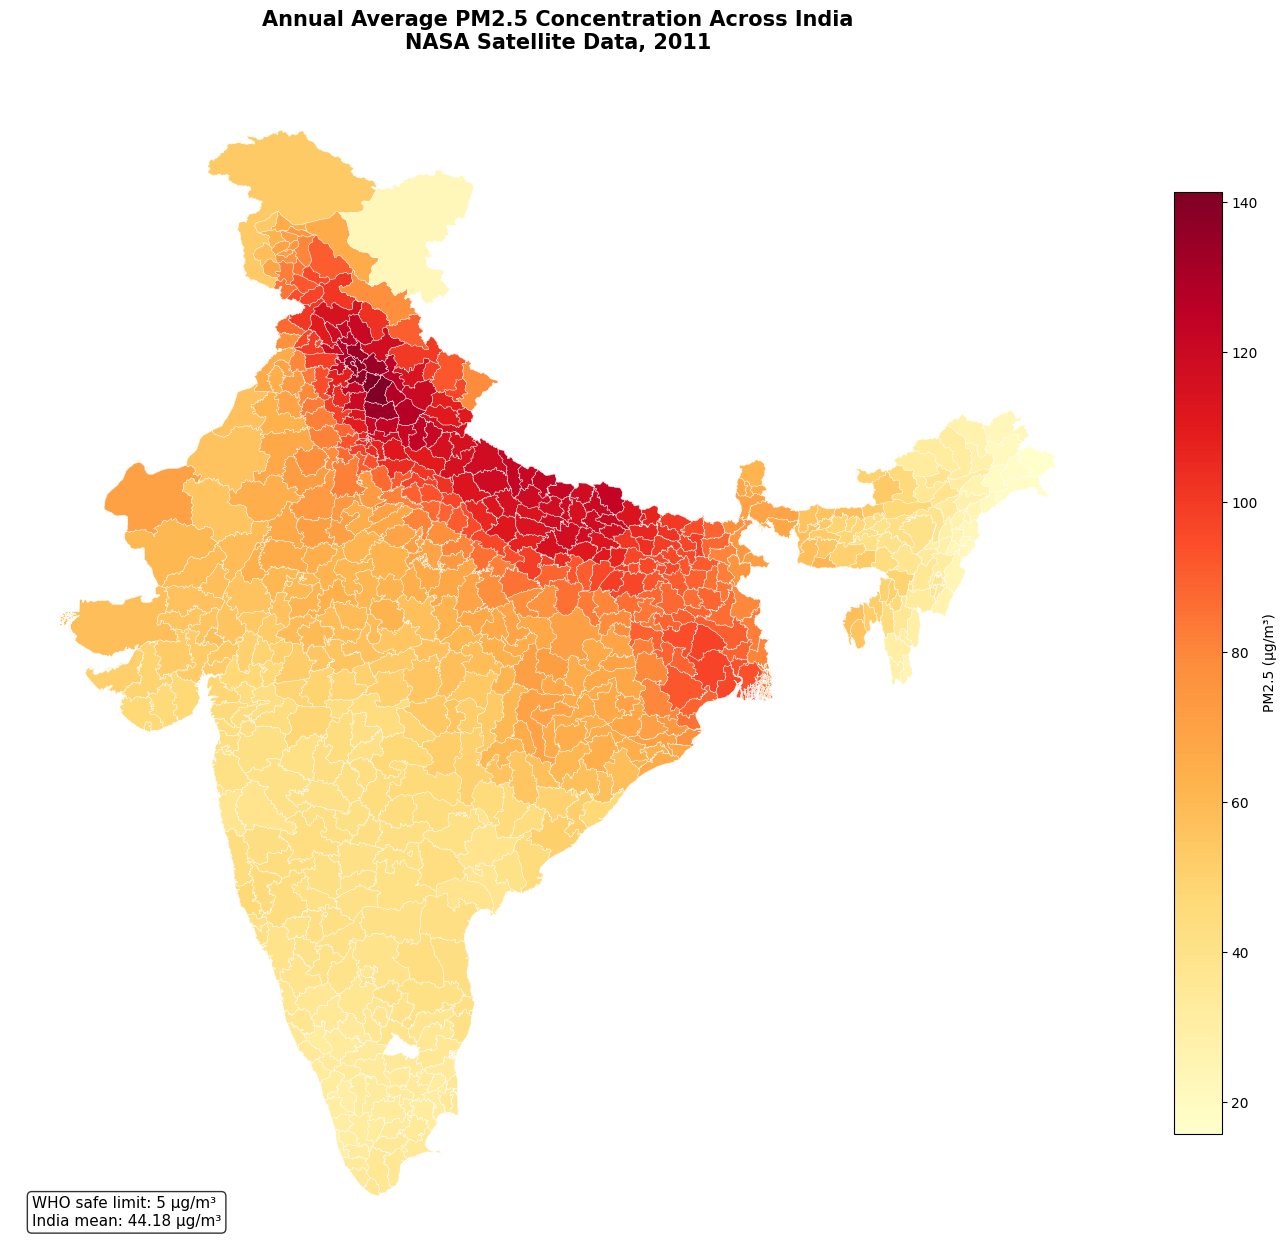

In [11]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fig, ax = plt.subplots(1, 1, figsize=(14, 16))
india.plot(ax=ax, column='PM25', cmap='YlOrRd',
           edgecolor='white', linewidth=0.3,
           legend=True,
           legend_kwds={'label': 'PM2.5 (µg/m³)', 'shrink': 0.6})

ax.set_title("Annual Average PM2.5 Concentration Across India\nNASA Satellite Data, 2011",
             fontsize=15, fontweight='bold', pad=20)
ax.axis('off')

# Adding WHO guideline note
ax.text(0.02, 0.02,
        "WHO safe limit: 5 µg/m³\nIndia mean: 44.18 µg/m³",
        transform=ax.transAxes, fontsize=11,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('india_pm25_map.png', dpi=200)
plt.show()

In [13]:
import pandas as pd
import numpy as np

# Fixing the fragmentation warning and column issue
india_clean = india.copy()
census_clean = df_census.copy()

india_clean['District_clean'] = india_clean['DISTRICT'].str.strip().str.title()
census_clean['District_clean'] = census_clean['District name'].str.strip().str.title()

# Checking what we have
print("India districts sample:", india_clean['District_clean'].head(5).tolist())
print("Census districts sample:", census_clean['District_clean'].head(5).tolist())

# Merging
df_merged = india_clean[['District_clean', 'ST_NM', 'PM25']].merge(
    census_clean[['District_clean',
                  'Population', 'Literate', 'Workers',
                  'Agricultural_Workers',
                  'Power_Parity_Less_than_Rs_45000',
                  'Power_Parity_Above_Rs_545000',
                  'Total_Power_Parity']],
    on='District_clean', how='inner')

# Building economic indicators
df_merged['Literacy_Rate']  = df_merged['Literate'] / df_merged['Population'] * 100
df_merged['Agri_Share']     = df_merged['Agricultural_Workers'] / df_merged['Workers'] * 100
df_merged['Poverty_Rate']   = df_merged['Power_Parity_Less_than_Rs_45000'] / df_merged['Total_Power_Parity'] * 100
df_merged['Affluence_Rate'] = df_merged['Power_Parity_Above_Rs_545000'] / df_merged['Total_Power_Parity'] * 100
df_merged = df_merged.dropna()

print(f"\nMerged successfully: {df_merged.shape[0]} districts")
df_merged[['District_clean', 'ST_NM', 'PM25', 'Poverty_Rate', 'Literacy_Rate']].head()

India districts sample: ['Adilabad', 'Agra', 'Ahmadabad', 'Ahmadnagar', 'Aizawl']
Census districts sample: ['Kupwara', 'Badgam', 'Leh(Ladakh)', 'Kargil', 'Punch']

Merged successfully: 622 districts


,District_clean,ST_NM,PM25,Poverty_Rate,Literacy_Rate
0,Adilabad,Andhra Pradesh,46.599998,15.498685,54.112283
1,Agra,Uttar Pradesh,81.099998,12.286861,60.661533
2,Ahmadabad,Gujarat,52.700001,3.295229,75.347802
3,Ahmadnagar,Maharashtra,40.900002,7.937047,69.376617
4,Aizawl,Mizoram,36.099998,4.776739,85.083023


Total districts merged: 622


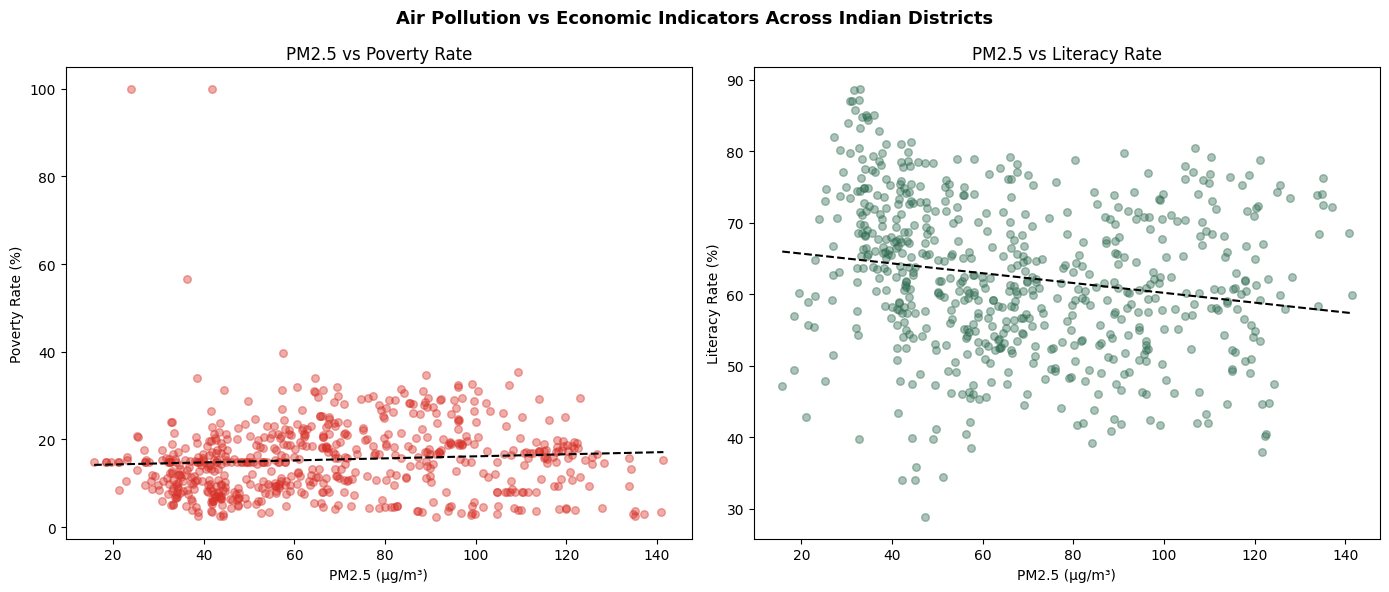


Correlation: PM2.5 vs Poverty Rate:    0.075
Correlation: PM2.5 vs Literacy Rate:   -0.187
Correlation: PM2.5 vs Agri Share:      0.052
Correlation: PM2.5 vs Affluence Rate:  0.064


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import numpy as np

print("Total districts merged:", len(df_merged))

# ── 1. Scatter: PM2.5 vs Poverty Rate ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1
axes[0].scatter(df_merged['PM25'], df_merged['Poverty_Rate'],
                alpha=0.4, color='#d73027', s=30)
z = np.polyfit(df_merged['PM25'], df_merged['Poverty_Rate'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_merged['PM25'].min(), df_merged['PM25'].max(), 100)
axes[0].plot(x_line, p(x_line), 'k--', linewidth=1.5)
axes[0].set_xlabel('PM2.5 (µg/m³)')
axes[0].set_ylabel('Poverty Rate (%)')
axes[0].set_title('PM2.5 vs Poverty Rate')

# Plot 2
axes[1].scatter(df_merged['PM25'], df_merged['Literacy_Rate'],
                alpha=0.4, color='#2D6A4F', s=30)
z2 = np.polyfit(df_merged['PM25'], df_merged['Literacy_Rate'], 1)
p2 = np.poly1d(z2)
axes[1].plot(x_line, p2(x_line), 'k--', linewidth=1.5)
axes[1].set_xlabel('PM2.5 (µg/m³)')
axes[1].set_ylabel('Literacy Rate (%)')
axes[1].set_title('PM2.5 vs Literacy Rate')

plt.suptitle('Air Pollution vs Economic Indicators Across Indian Districts',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pm25_vs_economics.png', dpi=150)
plt.show()

# ── 2. Correlation ─────────────────────────────────────────────────────────────
corr_poverty  = df_merged['PM25'].corr(df_merged['Poverty_Rate'])
corr_literacy = df_merged['PM25'].corr(df_merged['Literacy_Rate'])
corr_agri     = df_merged['PM25'].corr(df_merged['Agri_Share'])
corr_affluence= df_merged['PM25'].corr(df_merged['Affluence_Rate'])

print(f"\nCorrelation: PM2.5 vs Poverty Rate:    {corr_poverty:.3f}")
print(f"Correlation: PM2.5 vs Literacy Rate:   {corr_literacy:.3f}")
print(f"Correlation: PM2.5 vs Agri Share:      {corr_agri:.3f}")
print(f"Correlation: PM2.5 vs Affluence Rate:  {corr_affluence:.3f}")

Linear Regression Coefficients (predicting Poverty Rate):
     Variable  Coefficient
Literacy_Rate    -2.483145
         PM25     0.078944
   Agri_Share     2.480137

R² Score: 0.2239


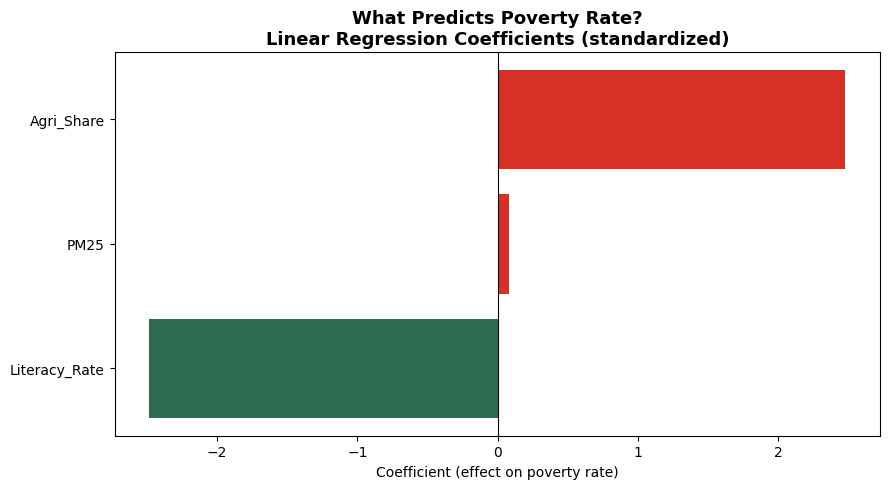

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# We want to know: does PM2.5 predict poverty After controlling for literacy and agricultural share?

X = df_merged[['PM25', 'Literacy_Rate', 'Agri_Share']].copy()
y = df_merged['Poverty_Rate'].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Linear regression with controls
lr = LinearRegression()
lr.fit(X_scaled, y)

coefficients = pd.DataFrame({
    'Variable': ['PM25', 'Literacy_Rate', 'Agri_Share'],
    'Coefficient': lr.coef_
}).sort_values('Coefficient', ascending=True)

print("Linear Regression Coefficients (predicting Poverty Rate):")
print(coefficients.to_string(index=False))
print(f"\nR² Score: {lr.score(X_scaled, y):.4f}")

# Plot coefficients
plt.figure(figsize=(9, 5))
colors = ['#d73027' if c > 0 else '#2D6A4F' for c in coefficients['Coefficient']]
plt.barh(coefficients['Variable'], coefficients['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title("What Predicts Poverty Rate?\nLinear Regression Coefficients (standardized)",
          fontsize=13, fontweight='bold')
plt.xlabel("Coefficient (effect on poverty rate)")
plt.tight_layout()
plt.savefig('regression_coefficients.png', dpi=150)
plt.show()

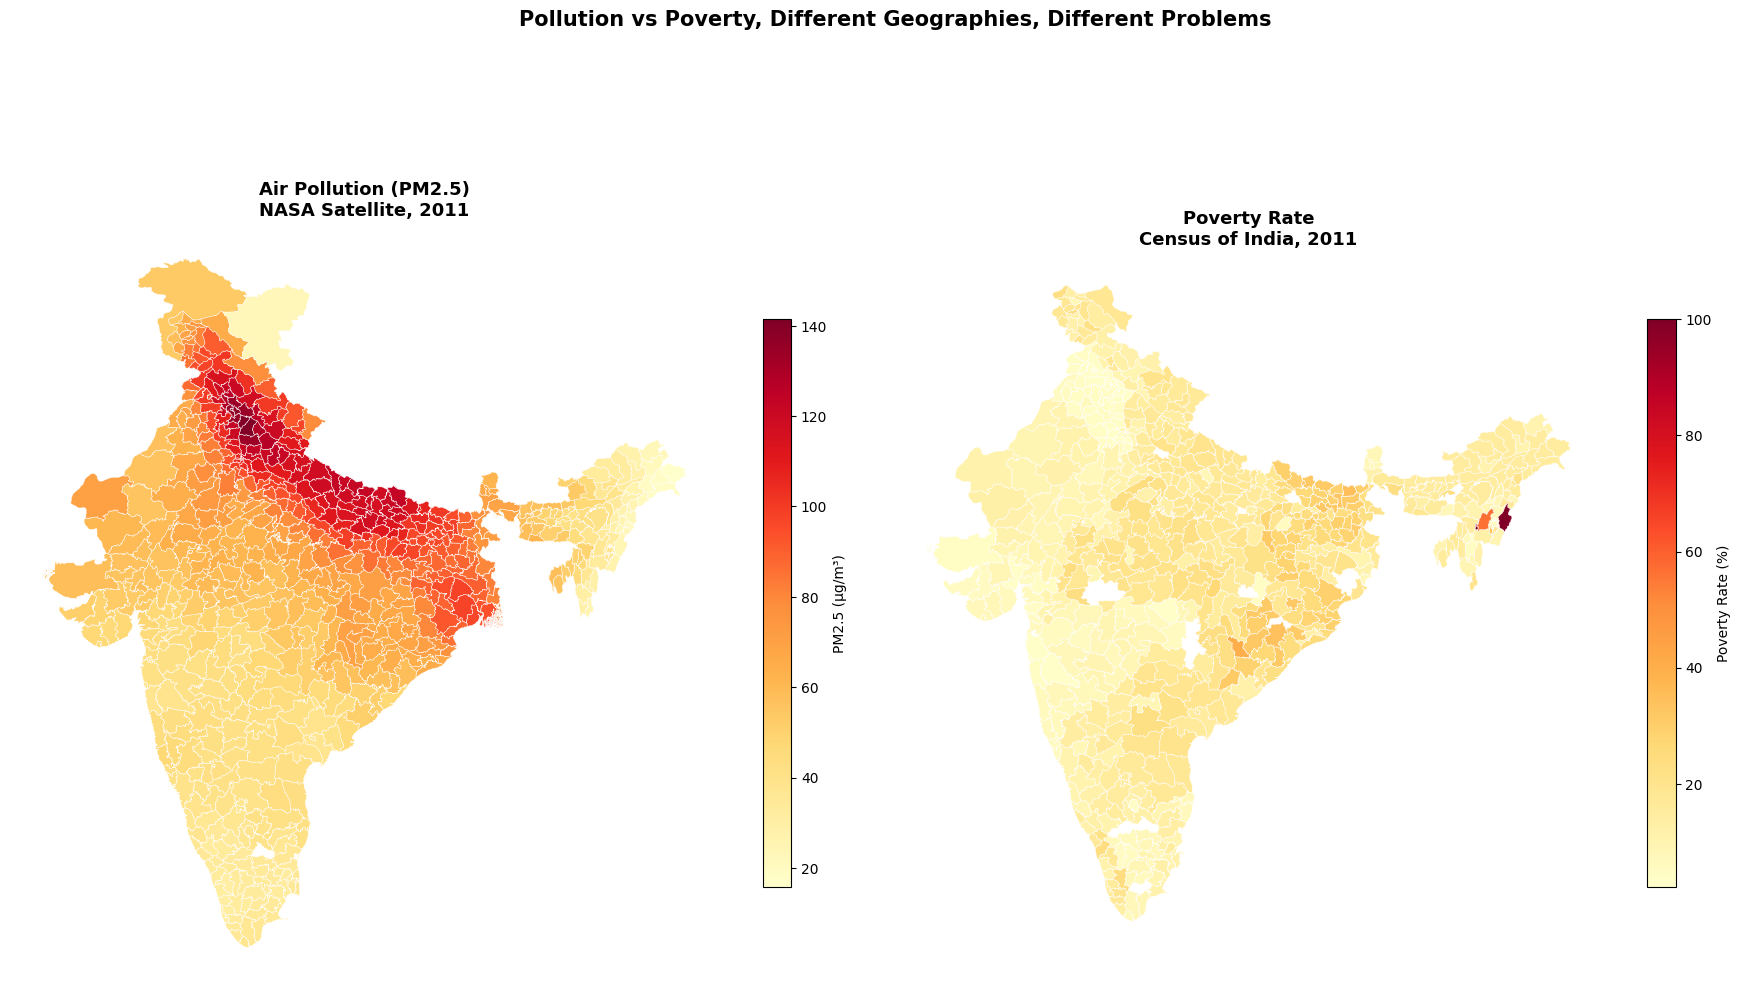

In [17]:
# Side by side map of pollution vs poverty
fig, axes = plt.subplots(1, 2, figsize=(18, 12))

# Merging poverty back into shapefile for mapping
india_plot = india_clean.merge(
    df_merged[['District_clean', 'Poverty_Rate']],
    on='District_clean', how='left')

# Map 1: PM2.5
india_clean.plot(ax=axes[0], column='PM25', cmap='YlOrRd',
                 edgecolor='white', linewidth=0.3,
                 legend=True,
                 legend_kwds={'label': 'PM2.5 (µg/m³)', 'shrink': 0.5})
axes[0].set_title("Air Pollution (PM2.5)\nNASA Satellite, 2011",
                  fontsize=13, fontweight='bold')
axes[0].axis('off')

# Map 2: Poverty
india_plot.plot(ax=axes[1], column='Poverty_Rate', cmap='YlOrRd',
                edgecolor='white', linewidth=0.3,
                legend=True,
                legend_kwds={'label': 'Poverty Rate (%)', 'shrink': 0.5})
axes[1].set_title("Poverty Rate\nCensus of India, 2011",
                  fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.suptitle("Pollution vs Poverty, Different Geographies, Different Problems",
             fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('pollution_vs_poverty_maps.png', dpi=200)
plt.show()